# Personalization Metric

In [2]:
# Install necessary libraries
# - datasets: GSM8K (math problems)
# - sentence-transformers: To convert text to vectors
# - scikit-learn: For PCA and distance calculations
!pip install --quiet datasets sentence-transformers scikit-learn matplotlib transformers accelerate tqdm

In [3]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

import torch
import json
import re
from tqdm import tqdm
from datasets import load_dataset
from transformers import pipeline

# 1. Mount Google Drive to save your work
# This will pop up a window asking for permission. Click "Allow".
drive.mount('/content/drive')

# 2. Create Project Folder
# This ensures your data is saved to your Drive, not just the temporary Colab session.
project_path = '/content/drive/My Drive/Geometric_Consistency_Project'
os.makedirs(project_path, exist_ok=True)
print(f"📂 Working Directory: {project_path}")

# 3. Check GPU
# We need a GPU for the local model to run fast.
if torch.cuda.is_available():
    print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ WARNING: No GPU detected. Go to Runtime -> Change Runtime Type -> Select T4 GPU")

print("✅ Setup Complete.")

Mounted at /content/drive
📂 Working Directory: /content/drive/My Drive/Geometric_Consistency_Project
✅ GPU Detected: Tesla T4
✅ Setup Complete.


## Phase 1: Data Generation (The Experiment)
### We generate 10 distinct reasoning paths for a set of math questions. We use a high temperature (0.7) to encourage diversity (and potential hallucinations).

Note: If USE_MOCK_DATA is True, we generate fake data to test the pipeline without spending money.

### Step 1: "Multiverse" generation

We are taking a single math problem (e.g., "What is 2+2?") and asking the AI to solve it 10 different times.

Why? If you ask an AI once, it might be right or wrong. If you ask it 10 times, you get a distribution of answers.

The Trick: We use a high "Temperature" (0.7). This forces the AI to be "creative" and try different reasoning paths.

The Goal: We want the AI to hallucinate a little bit. We need a mix of "Correct Reasoning" and "Weird/Wrong Reasoning" so we have something to filter out later.

In [4]:
# --- INSTALLATION (Run this once) ---
!pip install -q transformers accelerate datasets tqdm

import torch
import json
import re
from tqdm import tqdm
from datasets import load_dataset
from transformers import pipeline, AutoTokenizer

# 1. Setup Tokenizer & Model Explicitly
# We need to manually configure the tokenizer to fix the "Right Padding" warning
print("⏳ Loading Qwen2.5-1.5B-Instruct...")

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

# Load Tokenizer and force Left Padding
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"  # <--- FIXES THE WARNING
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token # Fix for models missing pad token

# Load Pipeline with our custom tokenizer
generator = pipeline(
    "text-generation",
    model=model_name,
    tokenizer=tokenizer,
    model_kwargs={"torch_dtype": torch.float16},
    device_map="auto",
)

# 2. Helper: Extract Answer
def extract_answer_number(text):
    explicit_match = re.search(r"[Tt]he answer is.*?(-?\d+\.?\d*)", text)
    if explicit_match:
        return float(explicit_match.group(1))
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", text)
    if numbers:
        return float(numbers[-1])
    return None

# 3. Optimized Data Generation
def generate_real_data(n_questions=20, n_paths=10):
    print(f"🚀 Starting Generation for {n_questions} questions...")

    ds = load_dataset("gsm8k", "main", split="test")

    prompts_list = []
    metadata_list = []

    for i in range(n_questions):
        q_text = ds[i]['question']
        gt_str = ds[i]['answer']
        ground_truth = extract_answer_number(gt_str)

        # Simple string format often works better for batching than list-of-dicts
        # We manually format the chat template to be safe
        prompt = f"<|im_start|>system\nYou are a math expert. Solve step-by-step. End with 'The answer is <number>'.<|im_end|>\n<|im_start|>user\n{q_text}<|im_end|>\n<|im_start|>assistant\n"

        prompts_list.append(prompt)
        metadata_list.append({"id": i, "question": q_text, "ground_truth": ground_truth})

    print("⚡ Running GPU Inference (Batched)...")

    # We use batch_size=8 which is usually safe for this small model on T4
    outputs = generator(
        prompts_list,
        max_new_tokens=256,
        batch_size=8,
        num_return_sequences=n_paths,
        temperature=0.1,
        do_sample=True,
        top_k=50,
        pad_token_id=tokenizer.pad_token_id # Explicitly pass pad token
    )

    generated_data = []
    for meta, output_batch in zip(metadata_list, outputs):
        # The pipeline output includes the prompt, we strip it to get just the response
        paths = []
        for item in output_batch:
            full_text = item['generated_text']
            # Remove the prompt part if it's included
            if full_text.startswith(meta['question']):
                 # heuristic fallback
                 clean_text = full_text
            else:
                 # Usually pipeline returns just the generated text or full text depending on settings
                 # For chat models, we just want the new content.
                 # With raw string prompts, it often returns full string.
                 # Let's simple split by 'assistant' tag if present or take last part
                 clean_text = full_text.split("<|im_start|>assistant")[-1].strip()

            paths.append(clean_text)

        generated_data.append({
            "id": meta['id'],
            "question": meta['question'],
            "ground_truth": meta['ground_truth'],
            "paths": paths
        })

    return generated_data

# --- EXECUTION ---
dataset = generate_real_data(n_questions=20, n_paths=10)

# Save
save_file = f"{project_path}/cot_data.json"
with open(save_file, "w") as f:
    json.dump(dataset, f, indent=2)

print(f"\n✅ SUCCESS! Saved {len(dataset)} questions to {save_file}")

⏳ Loading Qwen2.5-1.5B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

⚡ Running GPU Inference (Batched)...

✅ SUCCESS! Saved 20 questions to /content/drive/My Drive/Geometric_Consistency_Project/cot_data.json


## Phase 2: Embeddings & Latent Space
### We convert the text reasoning paths into dense vectors using sentence-transformers. This maps the "logic" into a geometric space.

Step 2: Vector Embedding

- We can't calculate the "distance" between two English sentences. Computers only understand numbers.

- The Tool: We use sentence-transformers (specifically all-mpnet-base-v2).

- The Action: It converts every reasoning path (e.g., "First I added 2...") into a list of 768 numbers (a vector).

- The Result: Now every reasoning path is a specific point in a 768-dimensional space. E.g.,
  - Path A (Correct) → Coordinate [0.1, 0.5, -0.2...]

  - Path B (Correct) → Coordinate [0.11, 0.49, -0.21...] (Very close to A)

  - Path C (Hallucination) → Coordinate [0.9, -0.8, 0.5...] (Far away)

In [5]:
# Compute Embeddings

# Load Model
embedder = SentenceTransformer('all-mpnet-base-v2')

# Load Data
with open(save_file, "r") as f:
    dataset = json.load(f)

# --- THE HACK: Prepend Answer to Text ---
def preprocess_for_embedding(paths):
    """
    Puts the answer at the start of the string.
    Old: "First I did X, then Y, so the answer is 4."
    New: "ANSWER IS 4. First I did X, then Y, so the answer is 4."
    """
    processed = []
    for p in paths:
        ans = extract_answer_number(p)
        # Force the vector to pay attention to the number immediately
        processed.append(f"ANSWER IS {ans}. {p}")
    return processed

# Test on the first question
example_idx = 0
paths = dataset[example_idx]['paths']
true_ans = dataset[example_idx]['ground_truth']

# Encode using the HACK
# We wrap 'paths' in our new function
vectors = embedder.encode(preprocess_for_embedding(paths))

print(f"✅ Encoded {len(vectors)} paths using the Answer-First Hack.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Encoded 10 paths using the Answer-First Hack.


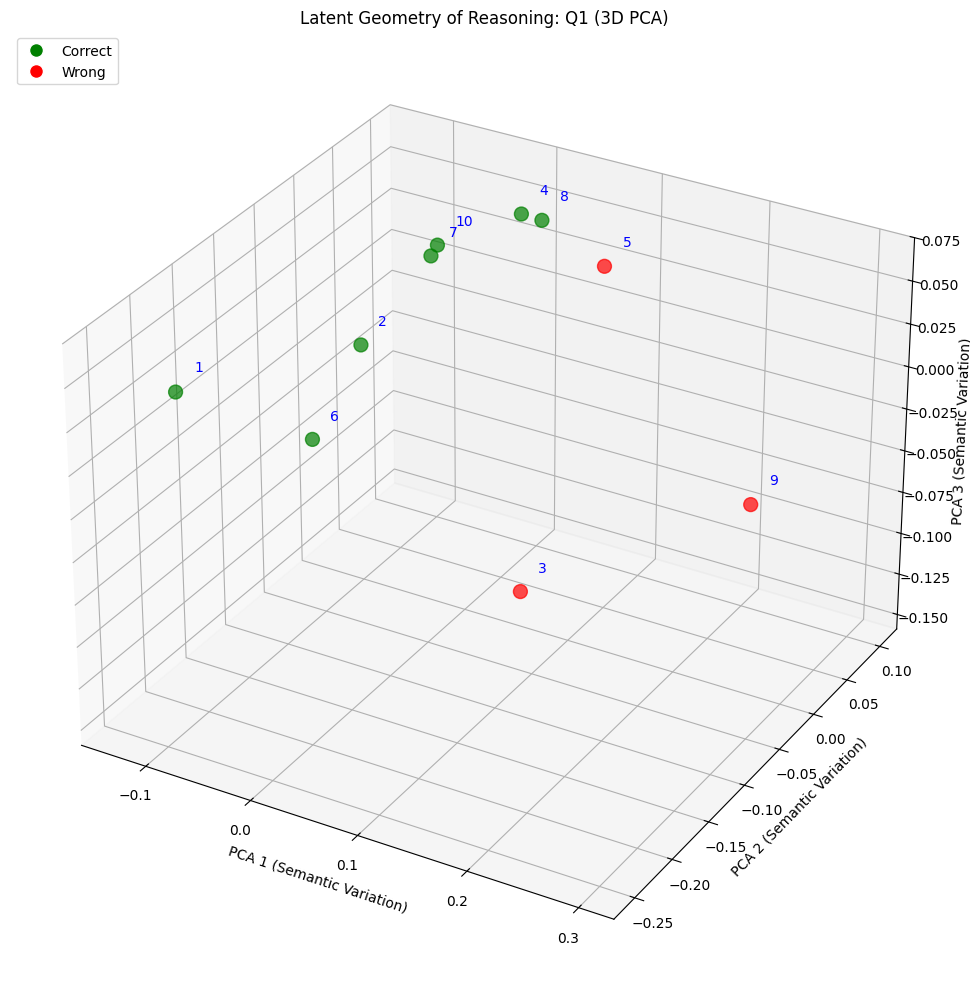

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

# --- Set example_idx for Question 5 (0-indexed) ---
example_idx = 0

# --- Recompute data for the selected question ---
# Load Data (assuming dataset is already loaded in the kernel)
# with open(save_file, "r") as f:
#     dataset = json.load(f)
# embedder = SentenceTransformer('all-mpnet-base-v2') # Assuming embedder is loaded

item = dataset[example_idx]
paths = item['paths']
true_ans = item['ground_truth']

# Encode using the HACK (preprocess_for_embedding and extract_answer_number must be in scope)
vectors = embedder.encode(preprocess_for_embedding(paths))

# 1. Compute Centroid
centroid = np.mean(vectors, axis=0).reshape(1, -1)

# 2. PCA Reduction to 3 components
all_points_3d = np.vstack([vectors, centroid])
pca_3d = PCA(n_components=3)
points_3d = pca_3d.fit_transform(all_points_3d)

path_points_3d = points_3d[:-1]
centroid_point_3d = points_3d[-1]

# 3. Determine Colors and Labels
colors = []
labels = []
for p in paths:
    pred = extract_answer_number(p)
    if pred == true_ans:
        colors.append('green')
        labels.append('Correct')
    else:
        colors.append('red')
        labels.append('Wrong')

# --- JITTER FIX for 3D --- (Add tiny random noise so dots don't overlap perfectly)
jitter_3d = np.random.normal(0, 0.005, path_points_3d.shape)
path_points_jittered_3d = path_points_3d + jitter_3d

# 4. Plot in 3D using Matplotlib
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for paths
scatter = ax.scatter(path_points_jittered_3d[:, 0],
                     path_points_jittered_3d[:, 1],
                     path_points_jittered_3d[:, 2],
                     c=colors, s=100, alpha=0.7, label='Reasoning Paths')

# Annotate with clearer text
for i, txt in enumerate(labels):
    ax.text(path_points_jittered_3d[i, 0]+0.01,
            path_points_jittered_3d[i, 1]+0.01,
            path_points_jittered_3d[i, 2]+0.01,
            f"{i+1}", color='blue')

ax.set_title(f"Latent Geometry of Reasoning: Q{example_idx+1} (3D PCA)")
ax.set_xlabel("PCA 1 (Semantic Variation)")
ax.set_ylabel("PCA 2 (Semantic Variation)")
ax.set_zlabel("PCA 3 (Semantic Variation)")

# Create a legend proxy for colors
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Correct', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Wrong', markerfacecolor='red', markersize=10),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout() # Added to ensure all labels are visible
plt.show()

# Todo:
- Use different dataset and add more models
- finetune and Rag implemnetation.
- Use clustering (k-means)
- Evaluation (consistency, coherence, fluency, coverage)